In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
path = "../data_pcb_smu/2026-02-25 new-wafer-1 device characterization/test_10_timesweep.csv"

# Channels to include (0-based index after the time column)
channels_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15]


Mean Drift: 11.7%
Std Drift: 2.6%


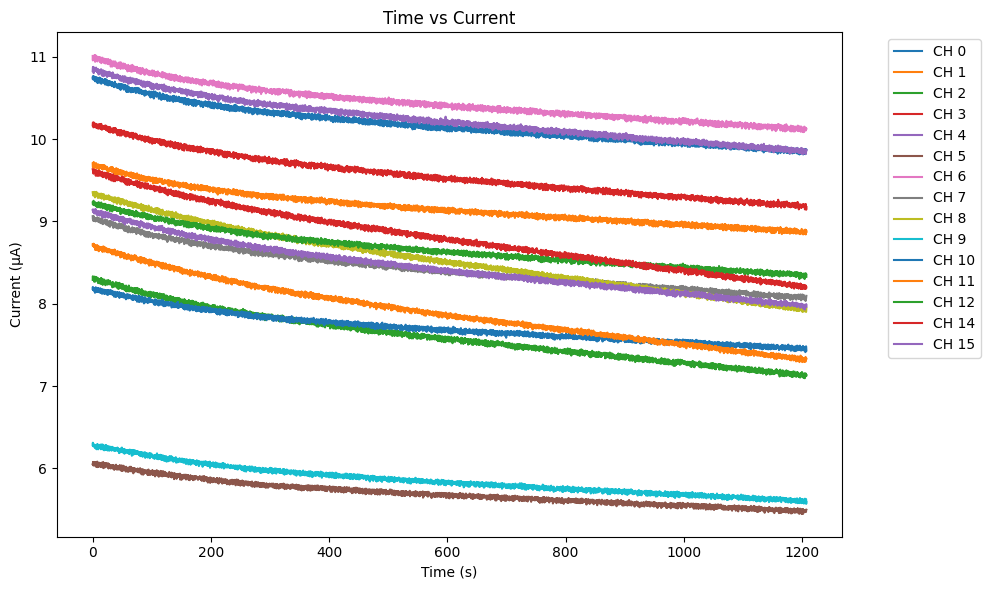

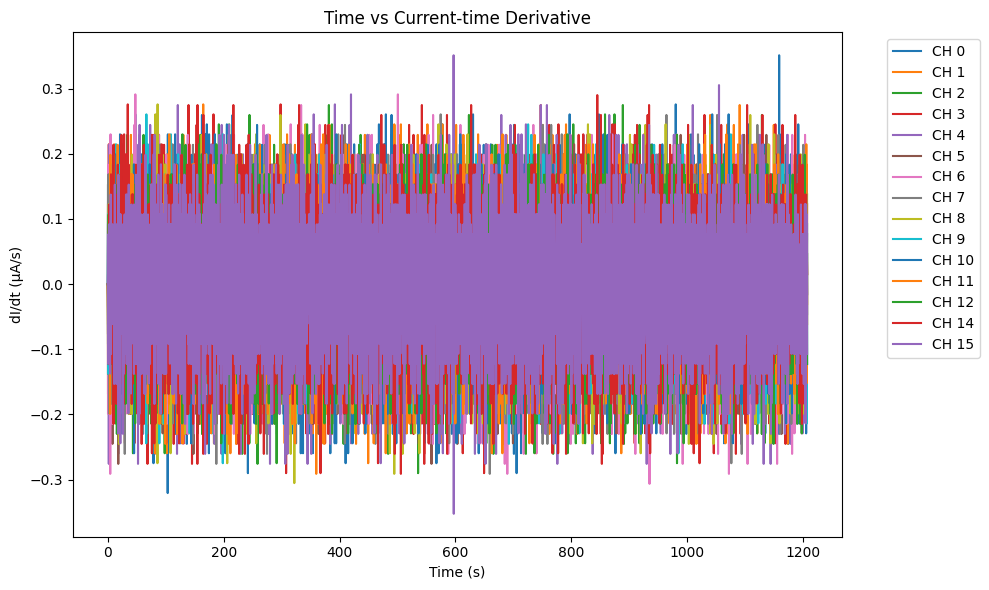

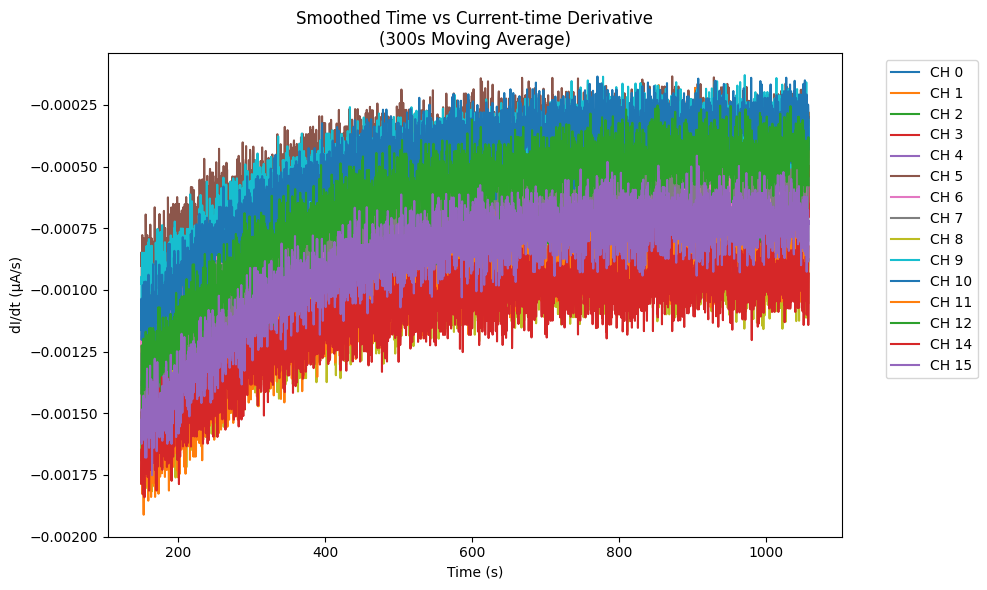

In [5]:
# Column names
time_col = "TIME"
current_cols = [f"I_CH{i}" for i in range(16)]
derivative_cols = [f"DI/DT{i}" for i in range(16)]


# Load CSV
df = pd.read_csv(path)
time = df[time_col]


# -------- Plot 1: Time vs Current --------
plt.figure(figsize=(10, 6))

drift_percent = []

for ch in channels_to_plot:
    # plot currents
    plt.plot(time, df[current_cols[ch]], label=f"CH {ch}")

    # Compute drift stats
    y_min = df[current_cols[ch]].min()
    y_max = df[current_cols[ch]].max()
    drift_percent.append((y_max - y_min) / y_max)

mean_drift_percent = np.mean(drift_percent) * 100
std_drift_percent = np.std(drift_percent) * 100
print(f"Mean Drift: {mean_drift_percent:.1f}%")
print(f"Std Drift: {std_drift_percent:.1f}%")


plt.xlabel("Time (s)")
plt.ylabel("Current (μA)")
plt.title("Time vs Current")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# -------- Plot 2: Time vs dI/dt --------
plt.figure(figsize=(10, 6))

for ch in channels_to_plot:
    plt.plot(time, df[derivative_cols[ch]], label=f"CH {ch}")

plt.xlabel("Time (s)")
plt.ylabel("dI/dt (μA/s)")
plt.title("Time vs Current-time Derivative")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# -------- Plot 3: Smoothed out Time vs dI/dt --------
dt = np.mean(np.diff(time))
window_seconds = 300
window_samples = int(window_seconds / dt)

plt.figure(figsize=(10, 6))

for ch in channels_to_plot:
    y = df[derivative_cols[ch]].values
    df_temp = pd.DataFrame({"time": time, "y": y})
    df_temp["y_avg"] = df_temp["y"].rolling(window=window_samples, center=True).mean()
    plt.plot(df_temp["time"], df_temp["y_avg"], label=f"CH {ch}")

plt.xlabel("Time (s)")
plt.ylabel("dI/dt (μA/s)")
plt.title(f"Smoothed Time vs Current-time Derivative\n({window_seconds}s Moving Average)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
